## Van der Pol oscillator

[(En) Period and extrema by nonlinear ODEs](https://shi200005-github-io.pages.dev/2025/10/26/Oscillation/).

$$
\frac{dx}{dt}=y, \\
\frac{dy}{dt}=\mu(1-x^2)y-x.
$$

First define the system of ODEs, the parameter is $\mu$, denote $\vec u=\begin{bmatrix} x \\ y \end{bmatrix}$.

### Numerical simulation

From fixed point analysis, the ODEs have an unstable spiral at $\vec u_{0}=\begin{bmatrix} 0 \\ 0 \end{bmatrix}$. The ODEs behave as a limit cycle oscillator. Then, if we simulate the ODEs from *any* initial condition (except for some trivial points, like the unstable fixed point here; the system will stay there), it will converge to the limit cycle oscillation. We set the parameter $\mu=1$, the initial condition $\vec u(0)=\begin{bmatrix} 0 \\ 1 \end{bmatrix}$. We calculate the numerical solution from $t_0=0$ to $t_f=30$.

First, let's use our handwritten RK4 solver with a fixed step length $h$ to solve the time trajectories and the phase portrait.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(u, mu):
    x, y = u
    return np.array([y, mu * (1.0 - x*x) * y - x], dtype=float)

def rk4_step(u, mu, h):
    k1 = f(u, mu)
    k2 = f(u + 0.5*h*k1, mu)
    k3 = f(u + 0.5*h*k2, mu)
    k4 = f(u + h*k3, mu)
    return u + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

mu = 1 # set the parameter value

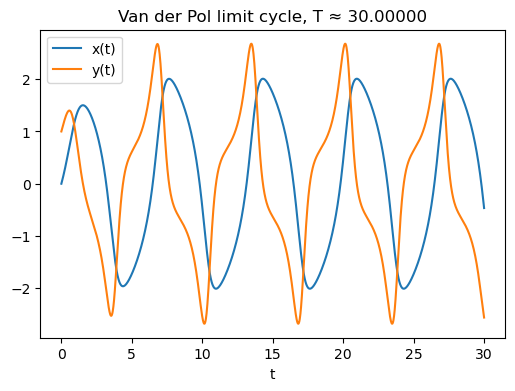

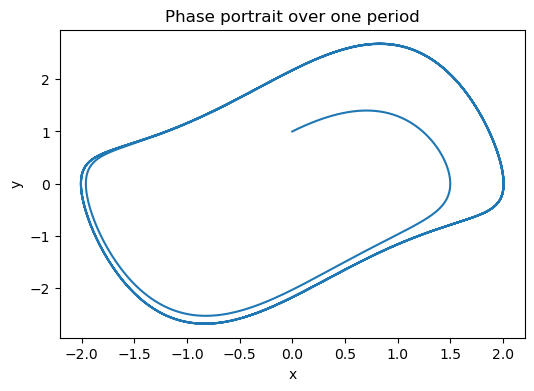

In [2]:
nplot = 2000 # time point num
tf = 30 # end time
h = tf / nplot # step length
u = np.zeros((nplot+1, 2)) # to store the solution

u0 = np.array([0.0, 1.0], dtype=float) # initial condition

u[0] = u0
for i in range(1, nplot+1):
    u[i] = rk4_step(u[i-1], mu, h)

# time trajectories
tgrid = np.linspace(0.0, tf, nplot+1)
plt.figure(figsize=(6,4))
plt.plot(tgrid, u[:,0], label='x(t)')
plt.plot(tgrid, u[:,1], label='y(t)')
plt.xlabel("t")
plt.legend()
plt.title(f"Van der Pol limit cycle, T ≈ {tf:.5f}")
plt.show()

# phase portrait
plt.figure(figsize=(6,4))
plt.plot(u[:,0], u[:,1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase portrait over one period")
plt.show()

We can also integrate by the RK4 method with ```scipy``` instead of writing the RK4 solver by hand. ```scipy.itegrate.solve_ivp``` has the adaptive step size.

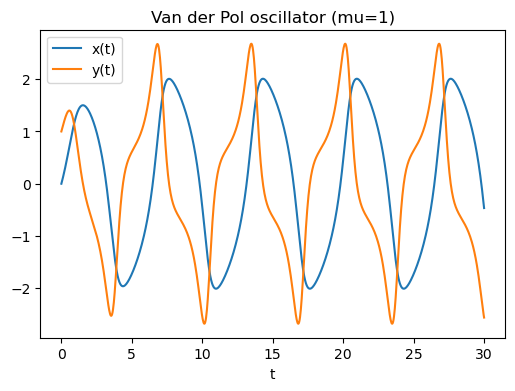

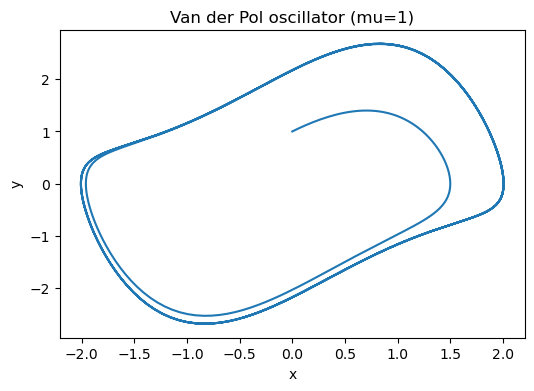

In [3]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def f_scipy(t, u, mu): # to use solve_ivp, we need to specify "t" here
    x, y = u
    return [y, mu * (1.0 - x*x) * y - x]

tf = 30
t_span = (0.0, tf)

u0 = [0.0, 1.0]
sol = solve_ivp(f_scipy, t_span, u0, args=(mu,), method="RK45", 
                rtol=1e-6, atol=1e-9, dense_output=True)

# time trajectories
t = np.linspace(*t_span, 1000)
x, y = sol.sol(t)

plt.figure(figsize=(6,4))
plt.plot(t, x, label='x(t)')
plt.plot(t, y, label='y(t)')
plt.xlabel("t")
plt.legend()
plt.title(f"Van der Pol oscillator (mu={mu})")
plt.show()

# phase portrait
plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Van der Pol oscillator (mu={mu})")
plt.show()

We can see the limit cycle oscillation, with period $T$ around 5~10, and maximum & minimum $x$ around $\pm$ 2, maximum & minimum $y$ around $\pm$ 2.8.

### Find $T$

It comes to solve a **boundary value problem** (BVP)

$$
\frac{d\vec u}{dt}= \vec f(\vec u)\\ 
\vec u(T)-\vec u(0)=\vec 0
$$

To determine this solution, we need to fix the starting point called $\vec u(0)$ on the closed oscillating trajectory. Then solving the above **BVP** boils down to solve 

$$
\vec g\left(\begin{bmatrix}x(0) \\ y(0) \\ T\end{bmatrix}\right) = \begin{bmatrix} x(T)-x(0) \\ y(T)-y(0) \\ y(0)\end{bmatrix}
$$

where $\begin{bmatrix} x(T)-x(0) \\ y(T)-y(0)\end{bmatrix}=\int_0^{T}\vec f(\vec u(t))dt-\vec u(0)$, and $y(0)$ chosen here to determine $\vec u(0)$. The problem is to find the root of $\vec g\left(\begin{bmatrix}x(0) \\ y(0) \\ T\end{bmatrix}\right)$ since $y(0)=0$ is indeed on the trajectory.

To solve this, we use multi-variable version [Newton-Raphson method](https://shi200005-github-io.pages.dev/limit/2025/02/02/Computational-Physics/#newton-raphson). 

In [4]:
# get x(t), y(t) from x(0), y(0) by intergrating the ODEs
def integrate(u0, t, nsteps=2000):
    h = t / nsteps
    u = np.array(u0, dtype=float)
    for _ in range(nsteps):
        u = rk4_step(u, mu, h)
    return u

# ---------- solve nonlinear g(z)=0，z=[x0, y0, T] ----------
def residual(z):
    x0, y0, T = z
    u0 = np.array([x0, y0], dtype=float)
    uT = integrate(u0, T)
    # periodic u(T) - u(0) = 0
    r_per = uT - u0
    # fix y0 = 0
    r_phase = np.array([y0])
    return np.concatenate([r_per, r_phase])  # x(T)-x(0)  y(T)-y(0)  y(0)

# Jabobian (finite difference)
def jacobian_fd(z, eps=1e-6):
    r0 = residual(z)
    J = np.zeros((3, 3), dtype=float)
    for j in range(3):
        zj = z.copy()
        zj[j] += eps
        rj = residual(zj)
        J[:, j] = (rj - r0) / eps
    return J

# ---------- Newton-Raphson ----------
def newton_solve(z0, max_iter=20, tol=1e-10):
    z = np.array(z0, dtype=float)
    for k in range(max_iter):
        r = residual(z)
        nr = np.linalg.norm(r, ord=2)
        # print(f"iter {k}: |r|={nr:.3e}, z={z}")
        if nr < tol:
            return z, True
        J = jacobian_fd(z)
        # solve J * dz = -r
        dz, *_ = np.linalg.lstsq(J, -r, rcond=None)
        z = z + dz
        # constrain T>0
        if z[2] <= 0:
            z[2] = max(1e-3, abs(z[2]))
        print(f"iter {k}: |r|={nr:.3e}, z={z}, continue\n")
    return z, False

# initial guess
z_guess = np.array([1.6, 0.0, 6.0]) 
# [x0, y0, T], which is acutally close to a solution
# make sure the period trajectory crosses y=0 if you fix y=0 here

# solve BVP
z_star, ok = newton_solve(z_guess, max_iter=25, tol=1e-11)
x0, y0, T = z_star
print("converged:", ok)
print(f"x0={x0:.8f}, y0={y0:.8f},  T={T:.8f}")

iter 0: |r|=6.511e-01, z=[2.0449148  0.         6.56993172], continue

iter 1: |r|=3.645e-01, z=[2.02707757 0.         6.66296166], continue

iter 2: |r|=5.709e-02, z=[ 2.00927025e+00 -1.76182853e-19  6.66299902e+00], continue

iter 3: |r|=2.455e-03, z=[2.00862125e+00 4.06575815e-20 6.66328639e+00], continue

iter 4: |r|=4.951e-06, z=[ 2.00861986e+00 -1.53524722e-21  6.66328686e+00], continue

iter 5: |r|=2.883e-11, z=[2.00861986 0.         6.66328686], continue

converged: True
x0=2.00861986, y0=0.00000000,  T=6.66328686


However, this method doesn't guarantee that the residue will converge to zero with random initial guess, for example,

In [5]:
# initial guess
z_guess_fail = np.array([1.0, 0.0, 5.0]) 

# solve BVP
z_star_fail, ok = newton_solve(z_guess_fail, max_iter=25, tol=1e-11)
x0_fail, y0_fail, T_fail = z_star_fail
print("converged:", ok)
print(f"x0={x0_fail:.8f}, y0={y0_fail:.8f},  T={T_fail:.8f}")

iter 0: |r|=2.618e+00, z=[1.21493618e+01 8.88178420e-16 1.51962920e+01], continue

iter 1: |r|=1.336e+00, z=[ 2.14529527e+01 -1.77635684e-15  1.33835325e+01], continue

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/var/folders/gv/v5_pzg5j53n7pshcq8rj8ky80000gn/T/ipykernel_1539/2921713674.py:6: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([y, mu * (1.0 - x*x) * y - x], dtype=float)
/var/folders/gv/v5_pzg5j53n7pshcq8rj8ky80000gn/T/ipykernel_1539/2921713674.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([y, mu * (1.0 - x*x) * y - x], dtype=float)
/var/folders/gv/v5_pzg5j53n7pshcq8rj8ky80000gn/T/ipykernel_1539/2921713674.py:13: RuntimeWarning: invalid value encountered in add
  return u + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)


LinAlgError: SVD did not converge in Linear Least Squares

But you expect it to work well (of course, the residue converge to zero) when your initial guess is close enough to the true solution. But (again), if your guess for $T$ is close enough to $nT$ ($n\in\Z^+$), the period will actually converge to that $nT$...

In [6]:
# initial guess
z_guess_doubleT = np.array([2.0, 0.0, 13.0]) 

# solve BVP
z_star_doubleT, ok = newton_solve(z_guess_doubleT, max_iter=25, tol=1e-11)
x0_doubleT, y0_doubleT, T_doubleT = z_star_doubleT
print("converged:", ok)
print(f"x0={x0_doubleT:.8f}, y0={y0_doubleT:.8f},  T={T_doubleT:.8f}")

iter 0: |r|=1.006e+00, z=[ 2.09953874  0.         13.36329786], continue

iter 1: |r|=2.372e-01, z=[2.01657457e+00 6.93889390e-18 1.33214749e+01], continue

iter 2: |r|=3.396e-02, z=[2.00887327e+00 8.67361738e-19 1.33265013e+01], continue

iter 3: |r|=8.791e-04, z=[ 2.00862004  0.         13.32657366], continue

iter 4: |r|=6.418e-07, z=[ 2.00861986  0.         13.32657372], continue

converged: True
x0=2.00861986, y0=0.00000000,  T=13.32657372


### Find extrema of all variables

From above, we've found one point on the trajectory ($(x(0), y(0))$) and the period $T$, then we can sample one period and find the extrema.

In [7]:
# return t_grid (len nplot+1) and traj (shape (nplot+1, nvars)).
def sample_one_period(u0, T, nplot=2000):
    h = T / nplot
    traj = np.zeros((nplot+1, len(u0)))
    tgrid = np.linspace(0.0, T, nplot+1)
    traj[0] = u0.copy()
    u = u0.copy()
    for i in range(1, nplot+1):
        u = rk4_step(u, mu, h)   
        traj[i] = u
    return tgrid, traj

# Three-point quadratic interpolation to find extreme values ​​and times 
# (ensuring the three points are adjacent when dealing with periodicity).
# Returns t_peak, x_peak.
# If the coefficient of the quadratic term is close to 0 (flat), 
# the midpoint may be returned.
def local_quadratic_peak(t_minus, x_minus, t_mid, x_mid, t_plus, x_plus):
    A = np.array([[t_minus**2, t_minus, 1.0],
                  [t_mid**2,   t_mid,   1.0],
                  [t_plus**2,  t_plus,  1.0]])
    y = np.array([x_minus, x_mid, x_plus])
    try:
        a, b, c = np.linalg.solve(A, y)
        if abs(a) < 1e-16:
            return t_mid, x_mid
        t_peak = -b / (2*a)
        x_peak = a*t_peak*t_peak + b*t_peak + c
        return t_peak, x_peak
    except np.linalg.LinAlgError:
        return t_mid, x_mid

# Find the maximum and minimum values ​​for each variable on the trajectory 
# (each variable may have multiple local peaks/valleys, 
# but typically the limiting cycle has only one dominant peak per period).
# Return a dictionary: { i: {'max': (t, value), 'min': (t, value)} }
def find_extrema_all_vars(tgrid, traj):
    npoints, nvars = traj.shape
    T = tgrid[-1]
    results = {}
    for i in range(nvars):
        x = traj[:, i]

        local_max_idx = []
        local_min_idx = []
        N = npoints
        for k in range(N):
            km = (k-1) % N 
            kp = (k+1) % N
            if x[k] > x[km] and x[k] >= x[kp]: # local maximum
                local_max_idx.append(k)
            if x[k] < x[km] and x[k] <= x[kp]: # local minimum
                local_min_idx.append(k)

        # If not found (which may occur with coarse numerical sampling), 
        # degenerate to the global max/min index.
        if len(local_max_idx) == 0:
            local_max_idx = [int(np.argmax(x))]
        if len(local_min_idx) == 0:
            local_min_idx = [int(np.argmin(x))]
            
        # Select the peak corresponding to the maximum (or minimum) 
        # from these local candidates (usually only one per period)
        # Refine the position using three-point quadratic interpolation
        # Handling periodicity: If the peak is at the boundary k=0 or k=N-1, 
        # use modular arithmetic to obtain three points
        def refine(idx_list, which='max'):
            best = None
            best_val = -np.inf if which=='max' else np.inf
            best_t = None
            for k in idx_list:
                km = (k-1) % N
                kp = (k+1) % N
                t_peak, x_peak = local_quadratic_peak(tgrid[km], x[km], tgrid[k], x[k], tgrid[kp], x[kp])
                # 归一化 t_peak 到 [0,T)
                t_peak = t_peak % T
                if which == 'max':
                    if x_peak > best_val:
                        best_val = x_peak; best = (t_peak, x_peak)
                else:
                    if x_peak < best_val:
                        best_val = x_peak; best = (t_peak, x_peak)
            return best

        max_pair = refine(local_max_idx, 'max')
        min_pair = refine(local_min_idx, 'min')
        results[i] = {'max': max_pair, 'min': min_pair,
                      'local_max_indices': local_max_idx,
                      'local_min_indices': local_min_idx}
    return results

In [14]:
tgrid, traj = sample_one_period(z_star[0:2], z_star[2], nplot=5000)
extrema = find_extrema_all_vars(tgrid, traj)
for i, info in extrema.items():
    tmax, xmax = info['max']
    tmin, xmin = info['min']
    print(f"var {i}: max={xmax:.6f} at t={tmax:.6f}, min={xmin:.6f} at t={tmin:.6f}")

var 0: max=2.006393 at t=3.331643, min=-2.008620 at t=3.331644
var 1: max=2.678441 at t=5.839207, min=-2.678441 at t=2.507564
